In [2]:
import pandas as pd
import numpy as np
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
from folium.features import GeoJsonTooltip
import matplotlib.patches as mpatches

os.chdir("/Users/adriensorin/Desktop/Documents ENSAE/2A/Python/Données/CSP")

In [9]:
Crimes_communes = pd.read_csv("./crimesdelitscommunes.csv")
Population_communes = pd.read_csv("/Users/adriensorin/Desktop/Documents ENSAE/2A/Python/Données/Population/popcommunes.csv")


/Users/adriensorin/opt/anaconda3/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3063: DtypeWarning: Columns (0,2) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [18]:
# On ne garde que la variable qui donne le nombre d'habitants de la commune en 2022
Population_communes_2022 = Population_communes[['dep', 'nomdep', 'codecommune', 'nomcommune', 'pop2022']]

In [19]:
Population_communes_2022 = Population_communes_2022[Population_communes_2022['nomdep'] == 'FINISTERE']


In [21]:
Population_communes_2022

,dep,nomdep,codecommune,nomcommune,pop2022
10275,29,FINISTERE,29001,ARGOL,967
10276,29,FINISTERE,29002,ARZANO,1371
10277,29,FINISTERE,29003,AUDIERNE,3673
10278,29,FINISTERE,29004,BANNALEC,5717
10279,29,FINISTERE,29005,BAYE,1298
...,...,...,...,...,...
10547,29,FINISTERE,29298,TRÉOGAT,573
10548,29,FINISTERE,29299,TRÉOUERGAT,338
10549,29,FINISTERE,29300,TRÉVOUX,1601
10550,29,FINISTERE,29301,TRÉZILIDÉ,433


In [20]:
Crimes_communes = Crimes_communes[Crimes_communes['nomdep'] == 'FINISTERE']
Crimes_communes_suffix = Crimes_communes.filter(regex="2020$")  #on étudie pour l'instant en 2022, on ne garde que les variables de 2022
Crimes_communes_2022 = Crimes_communes[["dep", "nomdep", "codecommune", "nomcommune"]].join(Crimes_communes_suffix)

In [22]:
communes_29 = gpd.read_file("/Users/adriensorin/Desktop/Documents ENSAE/2A/Python/Données/communes_29.geojson")
carte_Crimes_communes_2022 = pd.merge(communes_29, Crimes_communes_2022, left_on = 'code', right_on = 'codecommune',how='left')


In [23]:
carte_Crimes_communes_2022 = pd.merge(carte_Crimes_communes_2022, Population_communes_2022, left_on = 'code', right_on = 'codecommune',how='left')


In [27]:
# On pondère par nombre d'habitants

carte_Crimes_communes_2022['ncrimesdelits2022_pond'] = carte_Crimes_communes_2022['ncrimesdelits2020'] / carte_Crimes_communes_2022['pop2022']

/Users/adriensorin/opt/anaconda3/lib/python3.7/site-packages/geopandas/plotting.py:645: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  "Only specify one of 'column' or 'color'. Using 'color'.", UserWarning
/Users/adriensorin/opt/anaconda3/lib/python3.7/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:


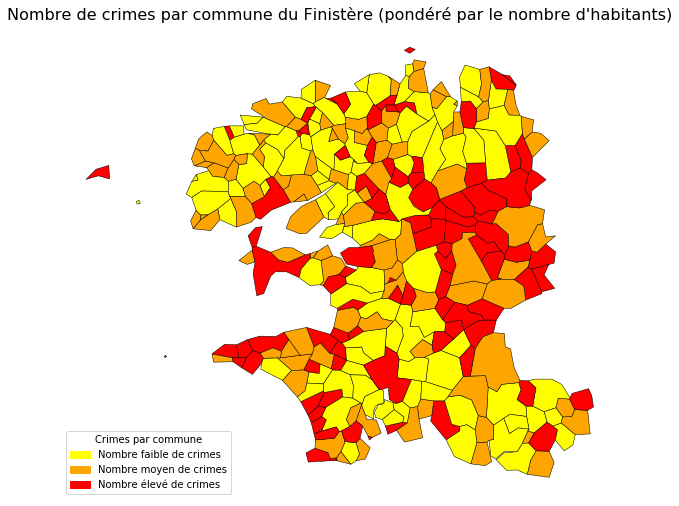

In [29]:
# On divise en trois catégories les communes : celles avec un PIB faible, moyen et élevé.
# La commande ci-dessous fait ça en divisant en trois catégories de tailles égales.
carte_Crimes_communes_2022['categorie_crimes'] = pd.qcut(carte_Crimes_communes_2022['ncrimesdelits2022_pond'], q=3, labels=['Nombre faible de crimes', 'Nombre moyen de crimes', 'Nombre élevé de crimes'])

# Définir la taille de la figure
fig, ax = plt.subplots(1, 1, figsize=(10, 12))


couleurs = {'Nombre faible de crimes':'yellow', 'Nombre moyen de crimes':'orange', 'Nombre élevé de crimes':'red'}

# Tracer la carte
carte_Crimes_communes_2022.plot(column='categorie_crimes',  # colonne à visualiser
              linewidth=0.5,          # contours des communes
              edgecolor='black',
              color=carte_Crimes_communes_2022['categorie_crimes'].map(couleurs),
              legend=True,            # afficher la légende
              ax=ax)

# Ajouter un titre
ax.set_title("Nombre de crimes par commune du Finistère (pondéré par le nombre d'habitants)", fontsize=16)

# Créer les patches pour la légende
patches = [mpatches.Patch(color=couleurs[key], label=key) for key in couleurs]

# Ajouter la légende
ax.legend(handles=patches, title="Crimes par commune", loc='lower left')

# Supprimer les axes
ax.set_axis_off()

# Afficher la carte
plt.show()

fig.savefig("/Users/adriensorin/Desktop/Documents ENSAE/2A/Python/Graphiques/crimes_commune.png", dpi=300, bbox_inches='tight')
